# <u>Support Vector Machines (SVM)</u>

A Support Vector Machines (SVM) is a binary linear classification whose decision boundary is explicitly constructed to <span style="color:red">minimize generalization error</span>. It is a very powerful and versatile Machine Learning model, capable of performing linear or nonlinear <span style="color:red">classification</span>, <span style="color:red">regression</span> and even <span style="color:red">outlier detection</span>. 

SVM is well suited for classification of complex but small or medium sized datasets.

**In other words...**

The objective of the support vector machine algorithm is to find a hyperplane in an N-dimensional space (where N is the number of features) that distinctly classifies the data points.

## What are Support Vectors?

<img src="https://www.dtreg.com/uploaded/pageimg/SvmMargin2.jpg" width="600" height="600">
 
Support vectors are the data points nearest to the dividing hyperplane, the points of a data set that, if removed, would alter the position of the dividing hyperplane. Because of this, they can be considered the critical elements of a dataset, they are what help us building our SVM. 

## What is a hyperplane?

<img src="http://slideplayer.com/slide/1579281/5/images/32/Hyperplanes+as+decision+surfaces.jpg" width="800" height="800">

Geometry tells us that a hyperplane is a subspace of one dimension less than its ambient space. For instance, a hyperplane of an n-dimensional space is a flat subset with dimension n − 1. By its nature, it separates the space into two half spaces.

### Separate two classes

To separate the two classes of data points, there are many possible hyperplanes that could be chosen. <span style="color:red">Our objective is to find a plane that has the maximum margin, i.e the maximum distance between data points of both classes</span>. Maximizing the margin distance provides some reinforcement so that future data points can be classified with more confidence.

<img src="https://cdn-images-1.medium.com/max/540/0*9jEWNXTAao7phK-5.png" width="300" height="300"> <img src="https://cdn-images-1.medium.com/max/540/0*0o8xIA4k3gXUDCFU.png" width="300" height="300">

## How does SVM classify?

It's important to start with the intuition for SVM with the **special linearly separable** classification case.

If classification of observations is **"<span style="color:red">linearly separable</span>"**, SVM fits the **"decision boundary"** that is defined by the largest margin between the closest points for each class. This is commonly called the **"maximum margin hyperplane (MMH)"**.

<img src="https://raw.githubusercontent.com/nalamidi/Breast-Cancer-Classification-with-Support-Vector-Machine/master/linear_separability_vs_not.png" width="800" height="800">

## Example: Classify Tumors

   Let's consider a dataset from the Sklearn library for classifying tumors into malignant (cancer) or benign using features obtained from several cell images.
   
   Features are computed from a digitized image of a fine needle aspirate (FNA) of a breast mass. They describe characteristics of the cell nuclei present in the image.
   
   
**Attribute Information:**
   
1.  ID number 
2.  Diagnosis (M = malignant, B = benign) 

**Ten real-valued features are computed for each cell nucleus:**

1. Radius (mean of distances from center to points on the perimeter) 
2. Texture (standard deviation of gray-scale values) 
3. Perimeter 
4. Area 
5. Smoothness (local variation in radius lengths) 
6. Compactness (perimeter^2 / area - 1.0) 
7. Concavity (severity of concave portions of the contour) 
8. Concave points (number of concave portions of the contour) 
9. Symmetry 
10. Fractal dimension ("coastline approximation" - 1)




### Import Python libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%pip install seaborn
import seaborn as sns

%matplotlib inline

#Import Cancer data from the Sklearn library
# Dataset can also be found here (http://archive.ics.uci.edu/ml/datasets/breast+cancer+wisconsin+%28diagnostic%29)

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import MinMaxScaler
cancer = load_breast_cancer()

### View the data in a dataframe

In [7]:
df_cancer = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df_cancer['target'] = pd.Series(cancer.target) # Note: target = 0 is Malignant (Cancer) and target = 1 is Benign (No Cancer)
df_cancer.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### Explore the dataset

In [19]:
df_cancer.shape

(569, 31)

We have 596 rows (Instances) and 31 columns(Features)

In [24]:
df_cancer.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='object')

Above is the name of each column in our dataframe.

### Visualize the data

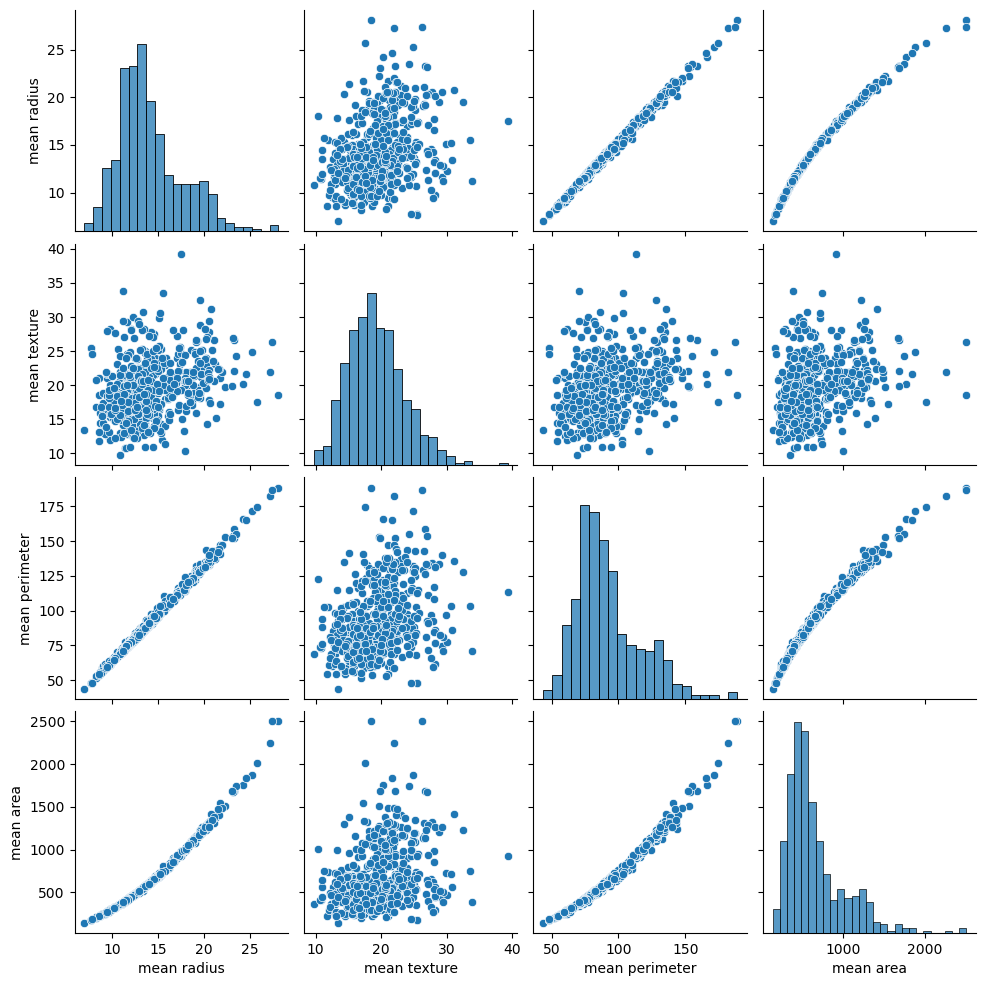

In [5]:
# Let's plot out just the first 5 variables (features)
sns.pairplot(df_cancer, vars = ['mean radius', 'mean texture', 'mean perimeter', 'mean area'] )

The above plots <span style="color:red">show the relationship between the features</span>. However, plots don't show which of the "dots" is Malignant and which is Benign. This will be addressed below by using the "target" variable.

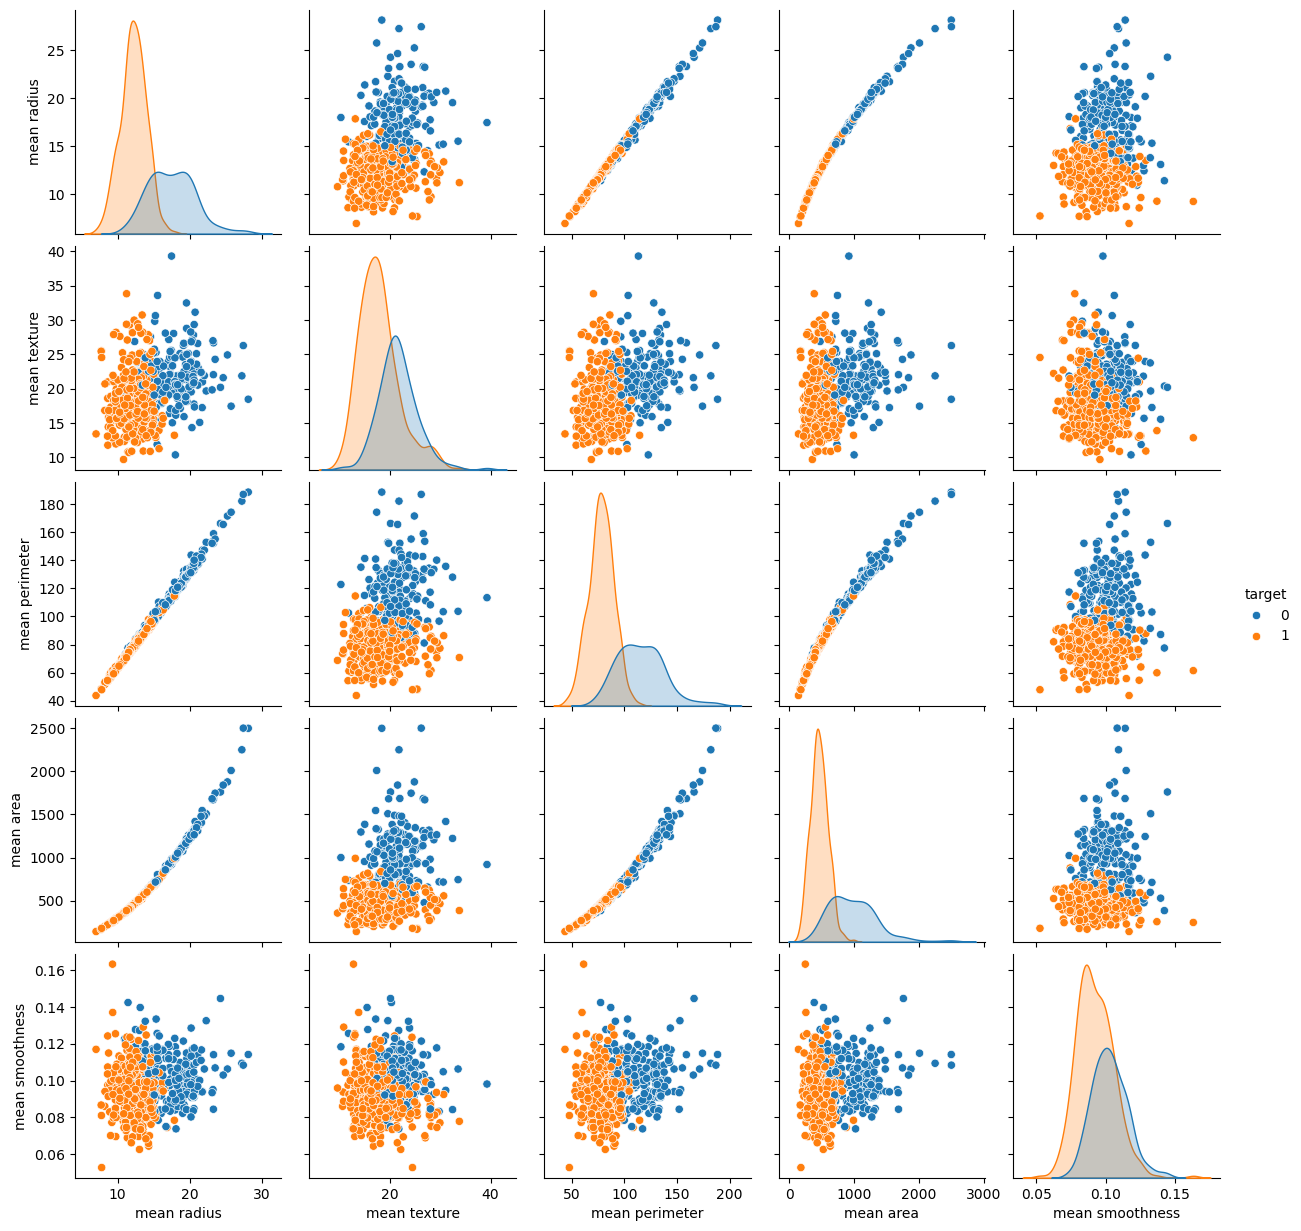

In [6]:
# Let's plot out just the first 5 variables (features)
sns.pairplot(df_cancer, hue = 'target', vars = ['mean radius', 'mean texture', 'mean perimeter','mean area','mean smoothness'] )

**Note:** 
    
  1.0 (Orange) = Benign (No Cancer)
  
  0.0 (Blue) = Malignant (Cancer)

### How many Benign and Malignant do we have in our dataset?

In [8]:
df_cancer['target'].value_counts()

1    357
0    212
Name: target, dtype: int64

As we can see, we have 212 - Malignant, and 357 - Benign

### Let's check the correlation between the features 

<AxesSubplot:>

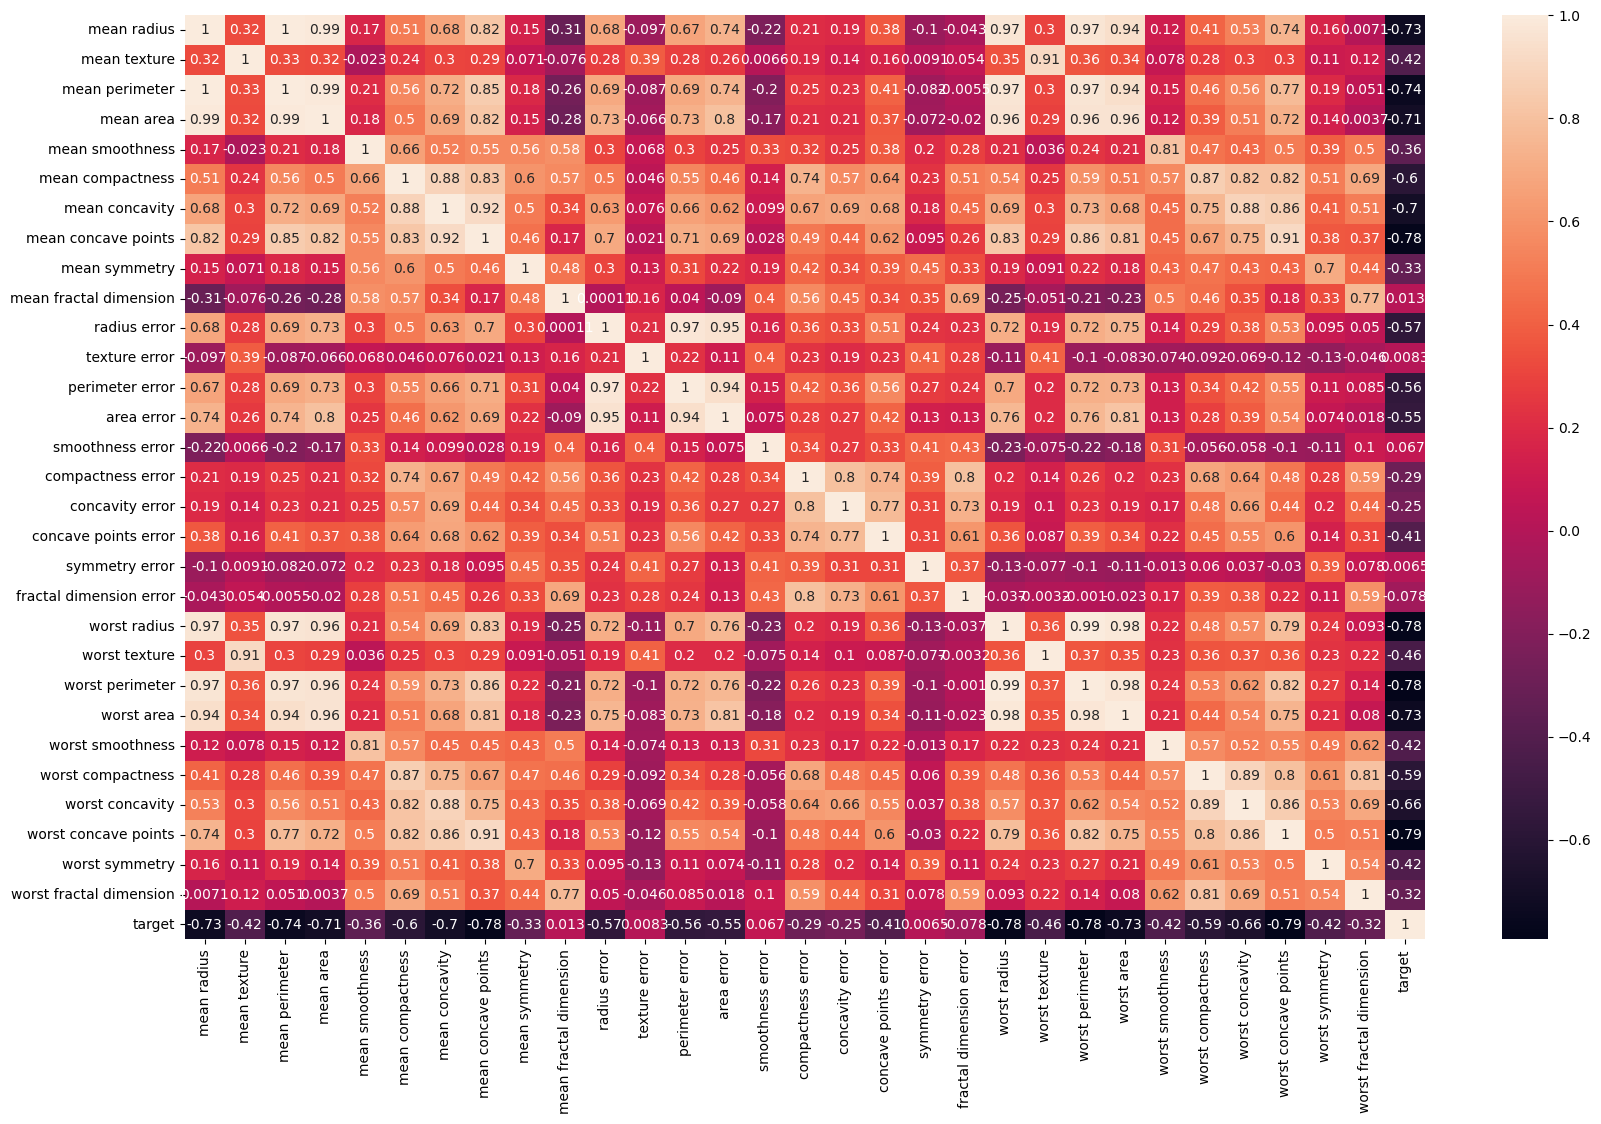

In [12]:
plt.figure(figsize=(20,12)) 
sns.heatmap(df_cancer.corr(), annot=True) 

For instance and according to the heatmap, there is a strong correlation between the mean radius and mean perimeter, mean area and mean primeter

# Model Training

**From our dataset, let's create the target and predictor matrix**

- "y" = is the feature we are trying to predict (Output). In this case we are trying to predict wheither our "target" is Cancer (Malignant) or not (Benign). I.e. we are going to use the "target" feature here.
- "X" = represents the predictors which are the remaining columns (mean radius, mean texture, mean perimeter, mean area, mean smoothness, etc)

In [13]:
#X = df_cancer.drop(['target'], axis = 1) # We drop our "target" feature and use all the remaining features in our dataframe to train the model.
#X.head()
#X = df_cancer.drop(['target'], axis = 'columns')
#X.head()

X = df_cancer.iloc[:, 0:30]  # all raws and the 1st 30 columns (i.e. all except 'target')
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [14]:
y = df_cancer['target']
y.head()

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int32

# Create the training and testing data

Now that we've assigned values to our "X" and "y", the next step is to import the python library that will help us to split our dataset into training and testing data.

In [15]:
from sklearn.model_selection import train_test_split

Remember:
- Training data: is the subset of our data used to train our model.
- Testing data: is the subset of our data that the model hasn't seen before. This is used to test the performance of our model.

Let's split our data using 80% for training and the remaining 20% for testing.

In [25]:
# reference for train_test_split: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 100) 
y_test.value_counts()

1    65
0    49
Name: target, dtype: int64

One final consideration is for **classification problems only**.

Some classification problems do not have a balanced number of examples for each class label. As such, it is desirable to split the dataset into train and test sets in a way that preserves the same proportions of examples in each class as observed in the original dataset.

This is called a stratified **train-test split**.

We can achieve this by setting the “**stratify**” argument to the "y" component (**target variable**) of the original dataset. This will be used by the train_test_split() function to ensure that both the train and test sets have the proportion of examples in each class that is present in the provided “y” array.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 10, stratify=y)
y_test.value_counts()

1    72
0    42
Name: target, dtype: int64

Let now check the size our training and testing data.

In [29]:
print ('The size of our training "X" (input features - X_train) is', X_train.shape)
print ('The size of our testing "X" (input features - X_test) is', X_test.shape)
print ('The size of our training "y" (output feature - Y_train) is', y_train.shape)
print ('The size of our testing "y" (output features - Y_test) is', y_test.shape)

The size of our training "X" (input features - X_train) is (455, 30)
The size of our testing "X" (input features - X_test) is (114, 30)
The size of our training "y" (output feature - Y_train) is (455,)
The size of our testing "y" (output features - Y_test) is (114,)


# Import the Support Vector Machine (SVM) Model 

In [30]:
# Support Vector Classifier
from sklearn.svm import SVC

# Try other kernels ("rbf" - Radial Based Function, "linear" - Linear and "poly" - Polynomial)
# C = Regularization
svc_algo = SVC(gamma="auto", kernel="rbf", C=1)

## Kernels

The SVM algorithm is implemented in practice using a kernel. A kernel transforms an input data space into the required form. SVM uses a technique called the kernel trick. Here, <u>the kernel takes a low-dimensional input space and transforms it into a higher dimensional space. In other words, you can say that it converts nonseparable problem to separable problems by adding more dimension to it</u>. It is most useful in non-linear separation problem. The Kernel trick helps building a more accurate classifier.

The most used Kernels are:

- **Linear Kernel** A linear kernel can be used as normal dot product of any two given observations. The product between two vectors is the sum of the multiplication of each pair of input values.


- **Polynomial Kernel** A polynomial kernel is a more generalized form of the linear kernel. The polynomial kernel can distinguish curved or nonlinear input space.


- **Radial Basis Function Kernel** The Radial basis function kernel is a popular kernel function commonly used in support vector machine classification. RBF can map an input space in an infinite dimensional space.

<img src="https://qph.fs.quoracdn.net/main-qimg-866b6450fc8c20dbf5dbd6a404cfe58a">

## Tuning Hyperparameters

- **Kernel:** The main function of the kernel is to transform the given dataset input data into the required form. There are various types of functions such as linear, polynomial, and radial basis function (RBF). Polynomial and RBF are useful for non-linear hyperplane. Polynomial and RBF kernels compute the separation line in the higher dimension. In some of the applications, it is suggested to use a more complex kernel to separate the classes that are curved or nonlinear. This transformation can lead to more accurate classifiers.


- **Regularization:** Regularization parameter in python's Scikit-learn C parameter is used to maintain regularization. Here C is the penalty parameter, which represents misclassification or error term. The misclassification or error term tells the SVM optimization how much error is bearable. This is how you can control the trade-off between decision boundary and misclassification term. A smaller value of C creates a small-margin hyperplane and a larger value of C creates a larger-margin hyperplane.


- **Gamma**: A lower value of Gamma will loosely fit the training dataset, whereas a higher value of gamma will exactly fit the training dataset, which causes over-fitting. In other words, a low value of gamma considers only nearby points in calculating the separation line, while the a value of gamma considers all the data points in the calculation of the separation line.

<img src="https://amueller.github.io/COMS4995-s18/slides/aml-09-021418-support-vector-machines/images/img_4.png">

## Now, let's train our SVM model with our "training" dataset.

In [36]:
# svc_model.fit will train our model with the train subset (X_train, y_train)
model = svc_algo.fit(X_train, y_train)

## Let's use our trained model to make a prediction using our testing data

In [37]:
# predictions obtained by using our model (using x_test and keeping predictions in a variable y_predict)
y_predict = model.predict(X_test)

<span style="color:red">The next step is to check the accuracy of our prediction by comparing it to the output we already have (y_test). We are going to use a confusion matrix to compare.</span>
A confusion matrix is a matrix used for evaluating the performance of a classification model. It compares the actual target values with those predicted by the machine learning model.

<img src="https://miro.medium.com/v2/resize:fit:640/format:webp/1*jMs1RmSwnYgR9CsBw-z1dw.png" width="500" height="500"> [Suresh, 2020]

In [34]:
# Import metric libraries
from sklearn.metrics import classification_report, confusion_matrix

In [41]:
cm = confusion_matrix(y_test, y_predict, labels=[0,1])
confusion = pd.DataFrame(cm, index=['is_not_cancer', 'is_cancer'],
                         columns=['predicted_not_cancer','predicted_cancer'])
confusion

,predicted_not_cancer,predicted_cancer
is_not_cancer,0,42
is_cancer,0,72


<AxesSubplot:>

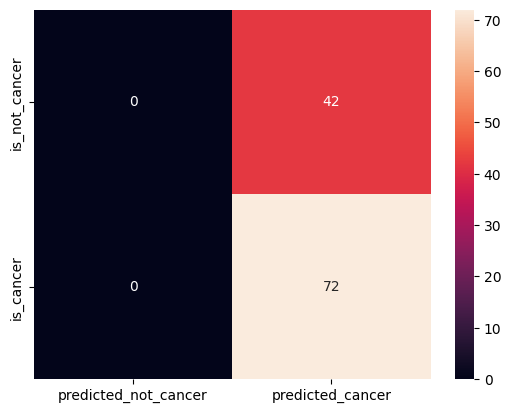

In [42]:
sns.heatmap(confusion, annot=True)

In [44]:
print(classification_report(y_test, y_predict, zero_division=0.0))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        42
           1       0.63      1.00      0.77        72

    accuracy                           0.63       114
   macro avg       0.32      0.50      0.39       114
weighted avg       0.40      0.63      0.49       114



With an accuracy of 0.63, our model did not do a very good job in its predictions (see [Suresh, 2020] to interpret the classification report in detail).

One way of improving the model is by changing kernels and its hyperparameters. However, let's explore another ways to improve the performance of the model.

## Improving our model

The first process we will try is by <b>normalizing</b> our data.

<u>Data Normalization is a feature scaling process that brings all values into range [0,1], or between [-1,1] or between any interval, which depends on the used scaler.</u>

**For the scaling between [0,1], it applies the following formula**:

<img src="https://miro.medium.com/max/682/0*8btMQlMD6O50pUDP">

Let's see what happens when we normalize or don't normalize data:

<img src="https://scikit-learn.org/0.18/_images/sphx_glr_plot_robust_scaling_001.png">

In order to normalize, we used a method from Sciki-learn called **MinMaxScaler**.

## Normalize Training Data

In [45]:
# crio o scaler (MinMaxScaler)
scaler = MinMaxScaler()

# Fit and Transform (fit vai decidir os valores, e o transform vai retornar esses valores)
X_train_scaled = scaler.fit_transform(X_train)

# criamos um novo dataset de treino, mas desta vez escalado
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_train_scaled.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,0.319892,0.340249,0.306337,0.187275,0.242033,0.125233,0.067502,0.066054,0.208586,0.117797,...,0.263607,0.278252,0.232980,0.132889,0.171300,0.170336,0.124920,0.206838,0.154741,0.128009
1,0.246533,0.148548,0.243867,0.132471,0.487226,0.222543,0.066893,0.143241,0.414141,0.306568,...,0.192458,0.154318,0.204044,0.088478,0.472363,0.253907,0.079193,0.281340,0.375320,0.316802
2,0.254579,0.501660,0.248704,0.136840,0.316783,0.220555,0.140933,0.186133,0.439394,0.292373,...,0.209890,0.492537,0.204442,0.095728,0.391138,0.240509,0.194409,0.414089,0.277351,0.318498
3,0.401297,0.405394,0.400180,0.256797,0.510698,0.307057,0.343486,0.401938,0.439899,0.163559,...,0.403059,0.372601,0.370985,0.238596,0.550948,0.232932,0.302796,0.520275,0.250739,0.213208
4,0.590137,0.399170,0.571557,0.434995,0.459240,0.296186,0.323102,0.426988,0.361616,0.131992,...,0.632159,0.334488,0.561233,0.439147,0.518589,0.317161,0.344808,0.686942,0.357579,0.292133


## Normalize Testing Data

In [46]:
scaler_2 = MinMaxScaler()
X_test_scaled = scaler_2.fit_transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)
X_test_scaled.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,0.186668,0.212457,0.165437,0.113111,0.450841,0.189412,0.102105,0.112225,0.305603,0.230422,...,0.187155,0.317763,0.171575,0.111441,0.349351,0.146511,0.148787,0.297991,0.241393,0.124692
1,0.259764,0.096194,0.235909,0.161964,0.524001,0.262296,0.118437,0.127874,0.000000,0.338353,...,0.239749,0.106945,0.234770,0.143880,0.479097,0.208151,0.153887,0.274720,0.150344,0.198561
2,0.797622,0.480623,0.781040,0.749252,0.685137,0.421811,0.725896,0.748317,0.370968,0.128012,...,0.895241,0.548863,0.883721,0.894256,0.675156,0.228079,0.432555,0.769208,0.231829,0.133284
3,0.259219,0.180623,0.231855,0.165155,0.489582,0.181706,0.144297,0.190688,0.303056,0.166667,...,0.218797,0.189920,0.199381,0.136103,0.447381,0.092588,0.133305,0.319645,0.207728,0.051489
4,0.048494,0.228720,0.030087,0.023031,0.635746,0.250407,0.132554,0.085658,0.190153,0.519327,...,0.056313,0.264290,0.057634,0.028176,0.629025,0.138891,0.112087,0.169842,0.208875,0.181909


## SVM with Normalized data

In [48]:
svc_algo = SVC(gamma="auto", kernel="linear")
model = svc_algo.fit(X_train_scaled, y_train)

In [49]:
y_predict_2 = model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_predict_2)

In [50]:
cm = confusion_matrix(y_test, y_predict_2, labels=[0,1])
confusion = pd.DataFrame(cm, index=['is_not_cancer', 'is_cancer'],
                         columns=['predicted_is_not_cancer','predicted_cancer'])
confusion

,predicted_is_not_cancer,predicted_cancer
is_not_cancer,42,0
is_cancer,3,69


<AxesSubplot:>

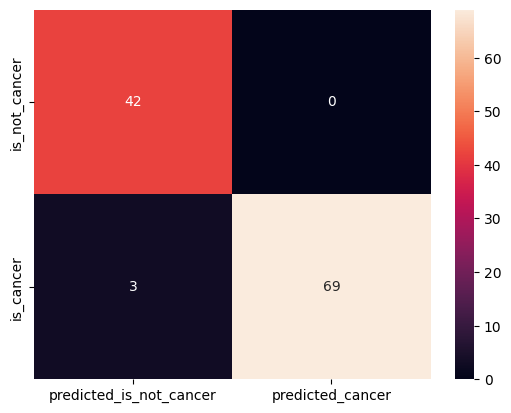

In [51]:
sns.heatmap(confusion, annot=True)

In [47]:
print(classification_report(y_test,y_predict_2))

              precision    recall  f1-score   support

           0       0.93      1.00      0.97        42
           1       1.00      0.96      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.98      0.97       114
weighted avg       0.98      0.97      0.97       114



**Awesome performance! We only have 3 false predictions.**

## Visualize using 2 features

In [62]:
# adapted from: http://bit.ly/2iv7FFL

def make_meshgrid(x, y, h=.02):
    x_min, x_max = x.min() - 1, x.max() + 1
    y_min, y_max = y.min() - 1, y.max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    return xx, yy

def plot_contours(ax, clf, xx, yy, **params):
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, **params)
    return out

def plot_model(model, x1, x2, title):

    X0, X1 = X.iloc[:, 0], X.iloc[:, 1]
    xx, yy = make_meshgrid(X0, X1)
    
    plt.figure()    
    plot_contours(plt, model, xx, yy, alpha=0.75)
    plt.scatter(X0, X1, c=y, s=15, alpha=0.95, edgecolors='#333333', linewidths=0.3) 
    plt.xlabel(x1)
    plt.ylabel(x2)
    plt.title(title)
    plt.show()

In [63]:
X = X.iloc[:,:2]

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=0)

svclf = SVC(kernel="rbf", gamma='auto')
svclf.fit(X_train, y_train)

y_predict = svclf.predict(X_test)
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       0.84      0.81      0.83        53
           1       0.89      0.91      0.90        90

    accuracy                           0.87       143
   macro avg       0.87      0.86      0.86       143
weighted avg       0.87      0.87      0.87       143



/lib/python3.11/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


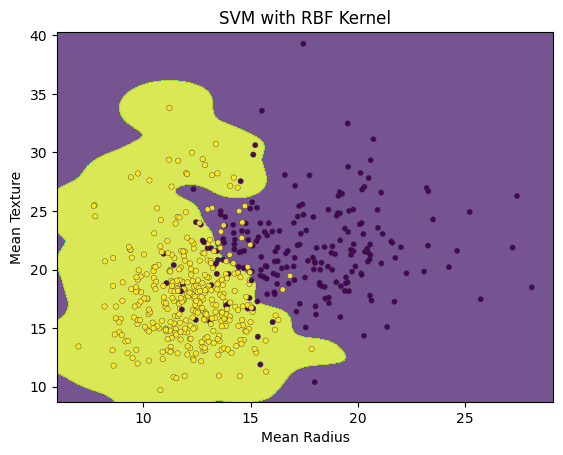

In [64]:
x1 = 'Mean Radius'
x2 = 'Mean Texture'
title = 'SVM with RBF Kernel'

plot_model(svclf, x1, x2, title)

### Can we do better by normalizing data?

### Normalize the new training set

In [59]:
scaler_3 = MinMaxScaler()
X_train_scaled_2 = scaler_3.fit_transform(X_train)
X_train_scaled_2 = pd.DataFrame(X_train_scaled_2, columns=X_train.columns)
X_train_scaled_2.head()

,mean radius,mean texture
0,0.230442,0.321577
1,0.200625,0.421162
2,0.622320,0.769295
3,0.312793,0.337344
4,0.459511,0.435270


### And the new test set

In [60]:
scaler_4 = MinMaxScaler()
X_test_scaled_2 = scaler_4.fit_transform(X_test)
X_test_scaled_2 = pd.DataFrame(X_test_scaled_2, columns=X_test.columns)
X_test_scaled_2.head()

,mean radius,mean texture
0,0.366320,0.343137
1,0.354047,0.508754
2,0.406369,0.172969
3,0.421872,0.260854
4,0.342420,0.269608


In [61]:
svclf2 = SVC(kernel="rbf", gamma='auto')
svclf2.fit(X_train_scaled_2, y_train)

y_predict_2 = svclf2.predict(X_test_scaled_2)
print(classification_report(y_test,y_predict_2))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87        53
           1       0.93      0.91      0.92        90

    accuracy                           0.90       143
   macro avg       0.89      0.90      0.90       143
weighted avg       0.90      0.90      0.90       143



**Yes! We did a little bit better. Normalizing data works!**

## Pros and Cons associated with SVM

### Pros:
- It works really well with clear margin of separation
- It is effective in high dimensional spaces.
- It is effective in cases where number of dimensions is greater than the number of samples.
- It uses a subset of training points in the decision function (called support vectors), so it is also memory efficient.

### Cons:
- It doesn’t perform well, when we have large data set because the required training time is higher
- It also doesn’t perform very well, when the data set has more noise i.e. target classes are overlapping
- SVM doesn’t directly provide probability estimates, these are calculated using an expensive five-fold cross-validation. - - It is related SVC method of Python scikit-learn library.

# Bibliography

[Suresh, 2020] Anuganti Suresh, 'What is a confusion matrix?', Medium, 2020, available at https://medium.com/analytics-vidhya/what-is-a-confusion-matrix-d1c0f8feda5 